(04-22-risk-management)=

# VaR, RiskMetrics en LTCM

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1994–1998, van RiskMetrics tot de redding van Long-Term Capital Management,
met een nasleep tot de Basel-regels van 2016.

**Wat we al weten.** [ARCH, GARCH en realized volatility](#04-21-volatiliteit) maakten
het tweede moment van dag tot dag voorspelbaar: volatiliteit clustert, en de afgelopen
weken zeggen veel over morgen. Uit [momentum crashes](#04-19-momentum) weten we dat een
strategie met een mooie Sharpe-ratio in drie maanden driekwart van haar waarde kan
verliezen.

**Welke vraag staat open.** Kan een bank of fonds met een voorspelbaar tweede moment zijn
kans op grote verliezen meten en begrenzen, en waarom was dat in 1998 niet genoeg?
```

## Overzicht

In oktober 1994 publiceerde J.P. Morgan RiskMetrics: een methode en gratis data waarmee
elke handelaar de *Value-at-Risk* (VaR: het verlies dat met een gegeven kans, zeg 99%,
over een gegeven horizon niet wordt overschreden) van zijn portefeuille kon uitrekenen.
De vierde editie van het *Technical Document* {cite}`JPMorganReuters1996` werd, naast het
leerboek van Jorion {cite}`Jorion2006`, het naslagwerk van een nieuw beroep. In januari
1996 maakte het Bazelse Comité VaR tot grondslag van het kapitaal tegen marktrisico
{cite}`BCBS1996a`, met een regel om de modellen achteraf te toetsen {cite}`BCBS1996b`.
Santa-Clara: "Out of the crash came a discipline the field had not had before: risk
management as a function, with its own numbers, staff and regulators"
{cite}`SantaClara2026`.

Epistemisch is VaR geen theorie over prijzen maar een meetinstrument, en een backtest
toetst geen evenwicht maar een voorspelling van een kwantiel. De toetsen komen van
{cite:t}`Kupiec1995` en {cite:t}`Christoffersen1998`, de eisen aan een goede risicomaat
van {cite:t}`ArtznerDelbaenEberHeath1999`. Hun conclusie dat VaR diversificatie kan
bestraffen, leidde in 2016 tot de overstap op *Expected Shortfall* (het gemiddelde verlies
voorbij het kwantiel) {cite}`BCBS2016`.

In september 1998 ging een fonds bijna failliet dat alles had wat de nieuwe discipline
voorschreef. Long-Term Capital Management (LTCM) had Robert Merton en Myron Scholes onder
zijn partners, een jaar na hun Nobelprijs {cite}`Lowenstein2000`. Santa-Clara's les
nummer tien: "Leverage plus mark-to-market plus a deadline is the recipe for ruin"
{cite}`SantaClara2026`. We leiden VaR, Expected Shortfall en de backtests af, laten zien
hoe weinig een backtest van 250 dagen ziet, en modelleren een gehefboomde arbitrageur met
positieve verwachte opbrengst en een hoge kans op ruïne. Aan het eind backtesten we vier
VaR-modellen op de Amerikaanse aandelenmarkt 1990–2026 en bekijken we de spreads van 1998.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from scipy import stats
from scipy.special import xlogy

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Een bank met honderden posities wil aan het eind van de dag één getal: hoeveel kunnen we
morgen verliezen? "De 99%-VaR is 40 miljoen" betekent dat het verlies op één dag op de
honderd groter mag zijn. Het getal telt obligaties, valuta en aandelen op in één munt,
beloont posities die elkaar opheffen, en vraagt alleen de spreiding van morgen, niet het
verwachte rendement, dat op één dag verwaarloosbaar is. Het slecht meetbare moment doet
er dus niet toe, het goed meetbare wel.

Er zijn drie zwakke plekken. De eerste noemt Santa-Clara: "the number was dangerous,
because it said nothing about the days that exceeded it, and the days that exceed it are
the only ones that matter" {cite}`SantaClara2026`. De tweede is dat een kwantiel van 1%
slecht te controleren is: in 250 handelsdagen verwacht je 2,5 overschrijdingen, en een
model dat maar 98% dekt, geeft er vaak ook niet meer dan vijf. De derde: VaR kan twee
obligaties samen riskanter noemen dan elk apart.

Dan LTCM. Het fonds kocht effecten die net iets goedkoper waren dan vrijwel identieke
andere en verkocht de duurdere, vooral in obligatiemarkten; ongeveer 80% van de
balansposities waren staatsobligaties van de G-7. Zo'n *convergence trade* (een positie
die winst maakt als twee prijzen naar elkaar toe bewegen) verdient een fractie van een
procent, dus moet je lenen. Op 31 augustus 1998 stond er meer dan 125 miljard dollar op
de balans, tegen 4,8 miljard eigen vermogen begin dat jaar: een hefboom van meer dan 25
{cite}`PresidentsWorkingGroup1999`, plus derivaten met een nominale waarde van meer dan
een biljoen dollar {cite}`Edwards1999`. Verbreden de spreads, dan ziet het fonds dat
dagelijks in zijn waardering (*mark-to-market*), vragen tegenpartijen extra onderpand, en
moet het verkopen vóór de convergentie. Dat is de deadline.

Als het fonds groot is, of veel fondsen dezelfde positie hebben, drukt de gedwongen
verkoop de prijs verder de verkeerde kant op, en dat verlies leidt tot de volgende
verkoop. Les nummer negen: "Liquidity is priced, and it disappears when you need it"
{cite}`SantaClara2026`. De Sharpe-ratio is bij elke hefboom dezelfde; de kans om de
periode te overleven waarin het rendement binnenkomt, niet.

## Toy-voorbeeld: twee posities, twee obligaties en een convergence trade

**(a) Parametrische VaR.** 100 miljoen in aandeel A (dagvolatiliteit 1,5%) en 50 miljoen
in B (1,0%), correlatie 0,4, verwachte rendementen nul. De posities hebben
standaarddeviaties van 1,5 en 0,5 miljoen, dus

$$
\sigma_p^2 = 1{,}5^2 + 0{,}5^2 + 2 \times 0{,}4 \times 1{,}5 \times 0{,}5 = 3{,}10,
\qquad \sigma_p = 1{,}7607 .
$$

Met $z_{0{,}99} = 2{,}3263$ is de 99%-VaR $4{,}096$ miljoen. Apart zijn de VaR's
$3{,}490$ en $1{,}163$, samen $4{,}653$: spreiding scheelt $0{,}557$ miljoen. Met de
wortel-uit-de-tijdregel is de VaR over tien dagen $\sqrt{10} \times 4{,}096 = 12{,}95$.

**(b) Twee obligaties.** Een obligatie levert 2 op, of verliest 100 als de uitgever
failleert (kans 4%). Bij 95% is de VaR het kleinste $\ell$ met $P(L > \ell) \le 5\%$;
omdat $P(L > -2) = 4\%$, is de VaR $-2$. Twee onafhankelijke obligaties verliezen $-4$
met kans $0{,}9216$, 98 met kans $0{,}0768$ en 200 met kans $0{,}0016$. Nu is
$P(L > -4) = 7{,}84\%$, en de VaR springt naar 98: veel meer dan de som van de VaR's,
$-4$. De Expected Shortfall op 95% middelt over de slechtste 5%: voor één obligatie
$(0{,}04 \times 100 + 0{,}01 \times (-2))/0{,}05 = 79{,}6$, voor twee
$(0{,}0016 \times 200 + 0{,}0484 \times 98)/0{,}05 = 101{,}26 < 159{,}2$. ES ziet het
voordeel van spreiden wel.

**(c) Een convergence trade.** Een fonds met eigen vermogen $E_0 = 100$ neemt een positie
$X = 25 E_0 = 2500$ in een spread met *spread duration* $D = 5$ (het verlies is $D$ maal
de verbreding maal de positie). De tegenpartij eist een *haircut* (het deel van de
positie dat met eigen geld gefinancierd moet zijn) van $h = 2\%$: $E \ge hX = 50$. Elk
basispunt kost $2500 \times 5 \times 0{,}0001 = 1{,}25$, dus de margin call komt na 40
basispunten en het vermogen is op na 80. Bij hefboom 10 kost een basispunt $0{,}5$ en komen
margin call en ruïne na 160 en 200 basispunten.

Stel nu dat elke verkoop van 100 de spread 1 basispunt verbreedt, en dat het fonds op de
grens ($E = 50$) nog 10 basispunten tegenwind krijgt. Het verlies is $12{,}5$, dus de
positie mag nog $37{,}5/0{,}02 = 1875$ zijn. De verkoop van 625 verbreedt de spread
$6{,}25$ basispunten en kost op de resterende positie
$1875 \times 5 \times 0{,}000625 = 5{,}86$; dan mag de positie nog 1582 zijn, wordt 293
verkocht, en kost dat nog $2{,}32$. Het proces convergeert naar een verlies van 22,0 in
plaats van 12,5, bij een spreadverbreding van 21,0 basispunten waarvan het fonds de helft
zelf veroorzaakte.

In [2]:
# (a) parametric VaR of two positions
w = np.array([100.0, 50.0])
sig = np.array([0.015, 0.010])
rho = 0.4
cov = np.array([[sig[0]**2, rho * sig[0] * sig[1]], [rho * sig[0] * sig[1], sig[1]**2]])
z99 = stats.norm.ppf(0.99)
sd_p = np.sqrt(w @ cov @ w)
var_p, var_each = z99 * sd_p, z99 * w * sig


def var_es_discrete(losses, probs, alpha):
    """VaR and Expected Shortfall at level alpha of a discrete loss distribution."""
    order = np.argsort(losses)
    loss, p = np.asarray(losses, float)[order], np.asarray(probs, float)[order]
    cdf = np.cumsum(p)
    var = loss[np.searchsorted(cdf, alpha - 1e-12)]
    tail_mass = np.clip(cdf - np.maximum(cdf - p, alpha), 0.0, None)
    return var, (tail_mass * loss).sum() / (1 - alpha)


# (b) two bonds with 4% default probability
var_1, es_1 = var_es_discrete([-2.0, 100.0], [0.96, 0.04], 0.95)
var_2, es_2 = var_es_discrete([-4.0, 98.0, 200.0], [0.96**2, 2 * 0.96 * 0.04, 0.04**2], 0.95)

# (c) levered convergence trade: thresholds and a fire-sale spiral
E0, D, H, KAPPA = 100.0, 5.0, 0.02, 1e-6       # kappa: spread widening per unit sold
thresholds = {L: (1e4 * (1 - H * L) / (L * D), 1e4 / (L * D)) for L in (10, 25)}
X, E = 2500.0, 50.0 - 2500.0 * D * 0.0010       # at the margin limit, then a 10bp shock
spread_move, rounds = 10.0, []
while True:
    X_new = max(E, 0.0) / H
    sold = X - X_new
    if sold < 1e-9:
        break
    widening = KAPPA * sold
    E -= X_new * D * widening
    spread_move += 1e4 * widening
    rounds.append((sold, 1e4 * widening, E))
    X = X_new

print(f"(a) sigma_p = {sd_p:.4f}, VaR_99 = {var_p:.3f}, losse VaR's = {var_each.round(3)}, "
      f"som = {var_each.sum():.3f}, 10 dagen = {var_p * np.sqrt(10):.2f}")
print(f"(b) één obligatie: VaR = {var_1:.1f}, ES = {es_1:.2f}; twee: VaR = {var_2:.1f}, ES = {es_2:.2f}")
print(f"(c) drempels (margin call, ruïne) in bp: {thresholds}")
print("    eerste twee rondes (verkocht, bp, E):", [tuple(round(float(v), 2) for v in x) for x in rounds[:2]])
print(f"    na convergentie: E = {E:.2f}, verlies = {50 - E:.2f}, spreadverbreding = {spread_move:.1f} bp")
print("code == handberekening:", np.allclose(
    [sd_p, var_p, var_each.sum(), var_1, es_1, var_2, es_2, 50 - E, spread_move],
    [1.7607, 4.096, 4.653, -2.0, 79.6, 98.0, 101.26, 22.0, 21.0], atol=0.051))

(a) sigma_p = 1.7607, VaR_99 = 4.096, losse VaR's = [3.49  1.163], som = 4.653, 10 dagen = 12.95
(b) één obligatie: VaR = -2.0, ES = 79.60; twee: VaR = 98.0, ES = 101.26
(c) drempels (margin call, ruïne) in bp: {10: (160.0, 200.0), 25: (40.0, 80.0)}
    eerste twee rondes (verkocht, bp, E): [(625.0, 6.25, 31.64), (292.97, 2.93, 29.32)]
    na convergentie: E = 28.01, verlies = 21.99, spreadverbreding = 21.0 bp
code == handberekening: True


## Theorie

### VaR en Expected Shortfall

Laat $W_t$ de waarde van een portefeuille zijn en $L_{t+1} = -(W_{t+1} - W_t)$ het verlies.
Kansen zijn conditioneel op de informatie op $t$; we schrijven $P_t$.

:::{prf:definition} Value-at-Risk
:label: def-risk-management-var

De Value-at-Risk op betrouwbaarheid $\alpha \in (0,1)$ is

```{math}
:label: eq-risk-management-var
\mathrm{VaR}_{\alpha,t} = \inf\left\{\ell \in \mathbb{R} : P_t\!\left(L_{t+1} > \ell\right) \le 1-\alpha\right\}.
```
:::

:::{prf:definition} Expected Shortfall
:label: def-risk-management-es

De Expected Shortfall op betrouwbaarheid $\alpha$ is

```{math}
:label: eq-risk-management-es
\mathrm{ES}_{\alpha,t} = \frac{1}{1-\alpha}\int_\alpha^1 \mathrm{VaR}_{u,t}\,\mathrm{d}u .
```

Bij een continue verdeling is dit $\E_t\!\left[L_{t+1} \mid L_{t+1} \ge \mathrm{VaR}_{\alpha,t}\right]$.
:::

De integraalvorm werkt ook voor verdelingen met atomen, zoals die van de obligaties.

*Waarom zou dit waar zijn?* Bij een normale verdeling ligt elk kwantiel een vast aantal
standaarddeviaties boven het gemiddelde. Voor de ES is dat aantal het gemiddelde van de
standaardnormale verdeling boven het kwantiel, dat verder in de staart ligt.

:::{prf:proposition} VaR en ES onder normaliteit
:label: prop-risk-management-normaal

Is $L_{t+1} \sim \mathcal{N}(\mu_L, \sigma^2)$ gegeven de informatie op $t$, dan is

```{math}
:label: eq-risk-management-normaal
\mathrm{VaR}_{\alpha} = \mu_L + \sigma z_\alpha,
\qquad
\mathrm{ES}_{\alpha} = \mu_L + \sigma \frac{\varphi(z_\alpha)}{1-\alpha},
\qquad z_\alpha = \Phi^{-1}(\alpha).
```
:::

:::{prf:proof}
Schrijf $L = \mu_L + \sigma Z$; een stijgende affiene transformatie behoudt kwantielen.
Voor de ES is $\E[Z \mid Z \ge z_\alpha] = \frac{1}{1-\alpha}\int_{z_\alpha}^\infty z\varphi(z)\,\mathrm{d}z = \frac{\varphi(z_\alpha)}{1-\alpha}$,
omdat $\varphi'(z) = -z\varphi(z)$. $\square$
:::

Voor $\alpha = 0{,}99$ is de VaR-factor $2{,}326$ en de ES-factor $2{,}665$; voor
$\alpha = 0{,}975$ is de ES-factor $2{,}338$. Onder normaliteit is de ES op 97,5% dus
bijna de VaR op 99%. Daarom koos het Comité in 2016 "a 97.5th percentile, one-tailed
confidence level" (paragraaf 181(b) van {cite}`BCBS2016`): het kapitaal blijft onder
normale verdelingen gelijk, en alleen dikke staarten kosten meer.

### Drie manieren om het kwantiel te schatten

Met gewichten $\mathbf{w}$ in euro, covariantiematrix $\boldsymbol{\Sigma}_t$ en verwachte
rendementen nul is de **parametrische** VaR

```{math}
:label: eq-risk-management-parametrisch
\mathrm{VaR}_{\alpha,t} = z_\alpha \sqrt{\mathbf{w}^\top \boldsymbol{\Sigma}_t \mathbf{w}} .
```

Zo werkte RiskMetrics ("In RiskMetrics, we assume that the mean value of daily returns is
zero", p. 92–93 van {cite}`JPMorganReuters1996`), met 95% en $1{,}65\,\sigma$; Bazel eiste
99%. **Historische simulatie** past de rendementen van de afgelopen $K$ dagen toe op de
huidige posities en leest het empirische kwantiel af: dikke staarten zonder
verdelingsaanname, maar traag, want een crash telt $K$ dagen mee en valt er dan in één
keer uit. **Filtered historical simulation** {cite}`HullWhite1998,BaroneAdesiGiannopoulosVosper1999`
deelt elk historisch rendement door de volatiliteit van toen en vermenigvuldigt het
kwantiel van die residuen met de volatiliteit van morgen: de vorm van de staart uit de
data, het niveau uit een volatiliteitsmodel.

### EWMA als speciaal geval van GARCH

*Waarom zou dit waar zijn?* RiskMetrics wilde voor 480 reeksen één schatter die snel op
schokken reageert en geen parameters per reeks vraagt. Een gemiddelde van gekwadrateerde
rendementen met exponentieel dalende gewichten doet dat, en blijkt een GARCH-model
waarin schokken nooit uitdoven.

De *exponentially weighted moving average* (EWMA) is

```{math}
:label: eq-risk-management-ewma
\sigma_{t+1}^2 = \lambda\,\sigma_t^2 + (1-\lambda)\,r_t^2
= (1-\lambda)\sum_{j=0}^{\infty} \lambda^j r_{t-j}^2 .
```

RiskMetrics koos de *decay factor* die de voorspelfout van de variantie over alle reeksen
minimaliseert: "the decay factor for the daily data set is 0.94, and the decay factor for
the monthly data set is 0.97" (§5.3.2.2, p. 100 van {cite}`JPMorganReuters1996`). Het
optimum per reeks liep uiteen van 0,835 tot 0,995 (tabel 5.8). Bij $\lambda = 0{,}94$
dragen de laatste $\ln 0{,}01/\ln 0{,}94 \approx 74$ dagen 99% van het gewicht (tabel 5.7).

GARCH(1,1) uit [de vorige lecture](#04-21-volatiliteit) {cite}`Engle1982,Bollerslev1986` is

```{math}
:label: eq-risk-management-garch
\sigma_{t+1}^2 = \omega + a\, r_t^2 + b\,\sigma_t^2 ,
```

met $a, b$ in plaats van de gebruikelijke $\alpha, \beta$, die hier al bezet zijn. EWMA is
het geval $\omega = 0$, $a = 1-\lambda$, $b = \lambda$, dus $a + b = 1$: het *integrated*
GARCH-model van {cite:t}`EngleBollerslev1986`, zonder eindig onvoorwaardelijk niveau.

:::{prf:proposition} Variantie over $k$ dagen
:label: prop-risk-management-horizon

Laat rendementen conditioneel ongecorreleerd zijn met gemiddelde nul. Onder GARCH(1,1) met
$a + b < 1$ en $\bar\sigma^2 = \omega/(1-a-b)$ is

```{math}
:label: eq-risk-management-horizon
\Var_t\!\left(\sum_{j=1}^{k} r_{t+j}\right)
= k\,\bar\sigma^2 + \frac{1-(a+b)^k}{1-(a+b)}\left(\sigma_{t+1}^2 - \bar\sigma^2\right).
```

Onder EWMA is de variantie over $k$ dagen $k\,\sigma_{t+1}^2$: de wortel-uit-de-tijdregel
is dan voor de variantie exact.
:::

:::{prf:proof}
De variantie van de som is de som van $\E_t[\sigma_{t+j}^2]$. Uit
[](#eq-risk-management-garch) en $\E_t[r_{t+j}^2] = \E_t[\sigma_{t+j}^2]$ volgt
$\E_t[\sigma_{t+j+1}^2] = \omega + (a+b)\E_t[\sigma_{t+j}^2]$, met oplossing
$\bar\sigma^2 + (a+b)^{j-1}(\sigma_{t+1}^2 - \bar\sigma^2)$. Tel op met de meetkundige reeks.
Bij $a + b = 1$, $\omega = 0$ is elke term $\sigma_{t+1}^2$. $\square$
:::

Bazel stond toe dat de VaR "scaled up to ten days by the square root of time" werd (B.4(c)
van {cite}`BCBS1996a`). Dat faalt om drie redenen. Onder GARCH keert de volatiliteit terug
naar haar gemiddelde; een kwantiel van dikstaartige dagrendementen maal $\sqrt{k}$ is niet
het kwantiel van de som; en de regel veronderstelt dat de positie tien dagen stilstaat en
dan tegen de marktprijs kan worden gesloten. Daarom vervingen de regels van 2016 de tien
dagen door *liquidity horizons* (de tijd om een positie zonder grote prijsdruk af te
bouwen) van 10 tot 120 dagen, paragraaf 181(c) en (k) van {cite}`BCBS2016`.

In [3]:
A_GARCH, B_GARCH = 0.08, 0.91   # daily GARCH(1,1), persistence 0.99


def horizon_ratio(state, k, a=A_GARCH, b=B_GARCH):
    """sqrt of true k-day variance over k * one-day variance, with sigma_{t+1}^2 = state * sigma_bar^2."""
    persistence = a + b
    true = k + (1 - persistence**k) / (1 - persistence) * (state - 1)
    return np.sqrt(true / (k * state))


states = [0.25, 1.0, 4.0, 16.0]
pd.DataFrame({f"k = {k}": [horizon_ratio(s, k) for s in states] for k in (10, 60, 250)},
             index=pd.Index(states, name="sigma_{t+1}^2 / sigma_bar^2")).round(3)

,k = 10,k = 60,k = 250
sigma_{t+1}^2 / sigma_bar^2,,,
0.25,1.064,1.317,1.702
1.00,1.000,1.000,1.000
4.00,0.983,0.903,0.725
16.00,0.979,0.878,0.638


Bij persistentie 0,99 is de fout over tien dagen klein (+6% bij een halve, −2% bij een
dubbele volatiliteit), over een jaar een factor twee. Voor de horizon van Bazel zijn de
staart en de liquiditeit het probleem, niet de mean reversion.

### Backtesting: Kupiec en Christoffersen

*Waarom zou dit waar zijn?* Geeft een model elke dag het juiste conditionele kwantiel, dan
is de kans op een overschrijding elke dag $p = 1-\alpha$, wat er eerder ook gebeurde. De
overschrijdingen zijn dan onafhankelijke muntworpen: het juiste aantal, zonder patroon.

Definieer de *hit sequence* $I_{t+1} = \mathbb{1}\{L_{t+1} > \mathrm{VaR}_{\alpha,t}\}$.

:::{prf:proposition} Hits zijn Bernoulli
:label: prop-risk-management-hits

Is $\mathrm{VaR}_{\alpha,t}$ het ware conditionele $\alpha$-kwantiel van een continu verdeeld
verlies, dan zijn de $I_{t+1}$ onafhankelijke Bernoulli-variabelen met kans $1-\alpha$.
:::

:::{prf:proof}
Per definitie is $P_t(I_{t+1} = 1) = 1-\alpha$, en $I_1, \dots, I_t$ zitten in de informatie
op $t$, dus $P(I_{t+1} = 1 \mid I_1, \dots, I_t) = 1-\alpha$. Dan is de kans op elk patroon
het product van de marginale kansen. $\square$
:::

{cite:t}`Kupiec1995` toetste het aantal. Met $x$ overschrijdingen in $T$ dagen en
$\hat\pi = x/T$ is de *proportion-of-failures*-toets

```{math}
:label: eq-risk-management-kupiec
\mathrm{LR}_{\mathrm{pof}} = -2\ln\frac{(1-p)^{T-x}p^{x}}{(1-\hat\pi)^{T-x}\hat\pi^{x}}
\;\overset{a}{\sim}\; \chi^2_1 .
```

{cite:t}`Christoffersen1998` toetste ook het patroon. Laat $n_{ij}$ tellen hoe vaak
$I_t = i$ werd gevolgd door $I_{t+1} = j$, met $\hat\pi_{01} = n_{01}/(n_{00}+n_{01})$,
$\hat\pi_{11} = n_{11}/(n_{10}+n_{11})$ en $\hat\pi$ de totale fractie. Tegen een
Markov-keten als alternatief is

```{math}
:label: eq-risk-management-christoffersen
\mathrm{LR}_{\mathrm{ind}} = -2\ln\frac{(1-\hat\pi)^{n_{00}+n_{10}}\hat\pi^{n_{01}+n_{11}}}
{(1-\hat\pi_{01})^{n_{00}}\hat\pi_{01}^{n_{01}}(1-\hat\pi_{11})^{n_{10}}\hat\pi_{11}^{n_{11}}}
\;\overset{a}{\sim}\; \chi^2_1,
\qquad
\mathrm{LR}_{\mathrm{cc}} = \mathrm{LR}_{\mathrm{pof}} + \mathrm{LR}_{\mathrm{ind}}
\;\overset{a}{\sim}\; \chi^2_2 .
```

$\mathrm{LR}_{\mathrm{cc}}$ toetst *conditional coverage*. Een statisch model met te weinig
overschrijdingen in rustige en te veel in drukke jaren kan het juiste totaal halen en toch
falen, omdat een overschrijding gisteren die van vandaag waarschijnlijker maakt.

Bazel telt alleen. Over de laatste 250 dagen staat het verkeerslicht op groen bij 0 tot 4
overschrijdingen, op geel bij 5 tot 9 en op rood bij 10 of meer: de grenzen waar de
binomiale kans op zoveel of minder onder een juist model 95% en 99,99% passeert. In het
gele gebied stijgt de vermenigvuldigingsfactor van minimaal 3 met 0,40 tot 0,85, in het
rode met 1 {cite}`BCBS1996a,BCBS1996b`. Het Comité schreef zelf dat "tests of this type are
limited in their power to distinguish an accurate model from an inaccurate model" (p. 5).

In [4]:
def kupiec_lr(hits, p=0.01):
    """Kupiec (1995) proportion-of-failures LR statistic; hits along the last axis."""
    # TODO: naar hap.stats
    hits = np.asarray(hits, float)
    T, x = hits.shape[-1], hits.sum(axis=-1)
    pi_hat = x / T
    return -2 * ((xlogy(T - x, 1 - p) + xlogy(x, p)) - (xlogy(T - x, 1 - pi_hat) + xlogy(x, pi_hat)))


def christoffersen_lr(hits, p=0.01):
    """Christoffersen (1998) independence and conditional-coverage LR statistics."""
    # TODO: naar hap.stats
    hits = np.asarray(hits, float)
    h0, h1 = hits[..., :-1], hits[..., 1:]
    n00, n01 = ((1 - h0) * (1 - h1)).sum(-1), ((1 - h0) * h1).sum(-1)
    n10, n11 = (h0 * (1 - h1)).sum(-1), (h0 * h1).sum(-1)
    pi01, pi11 = n01 / np.maximum(n00 + n01, 1), n11 / np.maximum(n10 + n11, 1)
    pi = (n01 + n11) / (n00 + n01 + n10 + n11)
    lr_ind = -2 * ((xlogy(n00 + n10, 1 - pi) + xlogy(n01 + n11, pi))
                   - (xlogy(n00, 1 - pi01) + xlogy(n01, pi01) + xlogy(n10, 1 - pi11) + xlogy(n11, pi11)))
    return lr_ind, kupiec_lr(hits, p) + lr_ind


k = np.arange(11)
basel = pd.DataFrame({"overschrijdingen": k,
                      "P(X <= k), p = 1%": stats.binom.cdf(k, 250, 0.01),
                      "P(X >= k), p = 2%": stats.binom.sf(k - 1, 250, 0.02),
                      "LR_pof": kupiec_lr(np.array([np.r_[np.ones(i), np.zeros(250 - i)] for i in k]))})
basel["zone"] = pd.cut(basel["overschrijdingen"], [-1, 4, 9, 250], labels=["groen", "geel", "rood"])
basel.round(4)

,overschrijdingen,"P(X <= k), p = 1%","P(X >= k), p = 2%",LR_pof,zone
0,0,0.0811,1.0000,5.0252,groen
1,1,0.2858,0.9936,1.1765,groen
2,2,0.5432,0.9609,0.1084,groen
3,3,0.7581,0.8779,0.0949,groen
4,4,0.8922,0.7378,0.7691,groen
5,5,0.9588,0.5613,1.9568,geel
6,6,0.9863,0.3840,3.5554,geel
7,7,0.9960,0.2363,5.4970,geel
8,8,0.9989,0.1313,7.7336,geel
9,9,0.9997,0.0661,10.2290,geel


De tweede kolom is tabel 2 van het Bazelse kader (89,22% bij vier, 95,88% bij vijf, 99,99%
bij tien). De derde kolom is het probleem: een model dat maar 98% dekt, geeft verwacht vijf
overschrijdingen, maar blijft met kans 44% groen. Kupiec verwerpt op 5% bij nul
($\mathrm{LR}_{\mathrm{pof}} = 5{,}0$) en bij zeven of meer overschrijdingen; vijf en zes
vallen erbinnen.

Dit is motief 1 in de staart. Een kans van 1% geschat uit 250 dagen heeft een
standaardfout van $\sqrt{0{,}01 \times 0{,}99/250} = 0{,}63$ procentpunt, 63% van de kans
zelf. Een VaR-model is niet op een jaar te beoordelen.

### Coherente risicomaten

*Waarom zou dit waar zijn?* Een risicomaat zegt hoeveel kapitaal naast een positie moet
staan. Een positie die altijd slechter uitpakt, vraagt meer; twee keer dezelfde positie
twee keer zoveel; een euro contant een euro minder; en twee posities samen niet meer dan
apart, anders loont het een bank op te splitsen en zijn limieten per afdeling zinloos.

:::{prf:definition} Coherente risicomaat
:label: def-risk-management-coherent

Een afbeelding $\rho$ van verliezen naar $\mathbb{R}$ is coherent
{cite}`ArtznerDelbaenEberHeath1999` als voor alle $L_1, L_2$, $c \ge 0$ en $m \in \mathbb{R}$:
(1) *monotoniteit*: $L_1 \le L_2$ bijna zeker $\Rightarrow \rho(L_1) \le \rho(L_2)$;
(2) *subadditiviteit*: $\rho(L_1 + L_2) \le \rho(L_1) + \rho(L_2)$;
(3) *positieve homogeniteit*: $\rho(cL_1) = c\,\rho(L_1)$;
(4) *translatie-invariantie*: $\rho(L_1 + m) = \rho(L_1) + m$.
:::

Het origineel formuleert de axioma's voor toekomstige nettowaarden; wij vertalen naar
verliezen, wat de tekens omdraait.

:::{prf:theorem} VaR is niet coherent, ES wel
:label: thm-risk-management-coherentie

VaR voldoet aan (1), (3) en (4), maar niet in het algemeen aan (2). ES voldoet aan alle
vier. Zijn $(L_1, L_2)$ gezamenlijk normaal, dan is VaR voor $\alpha \ge 1/2$ subadditief.
:::

:::{prf:proof}
:class: dropdown

*VaR.* (1), (3) en (4) volgen omdat kwantielen behouden blijven onder stijgende
transformaties. Toy-voorbeeld (b) is een tegenvoorbeeld voor (2): $98 > -4$.

*ES.* (1), (3) en (4) erft ES via [](#eq-risk-management-es). Voor (2) gebruiken we de
duale vorm {cite}`AcerbiTasche2002`

$$
\mathrm{ES}_\alpha(L) = \sup\left\{\E[L\,\xi] : 0 \le \xi \le \tfrac{1}{1-\alpha},\ \E[\xi] = 1\right\},
$$

waarvan het supremum wordt bereikt door $\xi$ maximaal te maken op de slechtste fractie
$1-\alpha$ van de uitkomsten (fractioneel op een atoom op de grens), wat het gemiddelde
van de bovenste kwantielen geeft. Een supremum van een som is hoogstens de som van de
suprema, dus $\mathrm{ES}_\alpha(L_1+L_2) \le \mathrm{ES}_\alpha(L_1) + \mathrm{ES}_\alpha(L_2)$.

*Normaal.* $\mathrm{VaR}_\alpha(L_1+L_2) = \mu_1 + \mu_2 + z_\alpha\sigma_{12}$ met
$\sigma_{12} = \sqrt{\sigma_1^2 + \sigma_2^2 + 2\rho\sigma_1\sigma_2} \le \sigma_1 + \sigma_2$,
en $z_\alpha \ge 0$. $\square$
:::

Het normale geval verklaart waarom de praktijk het probleem lang niet zag: bij aandelen en
valuta gedraagt VaR zich. Het gaat mis bij een kleine kans op een groot verlies:
kredietrisico, verkochte opties, convergence trades.

### De dynamiek van een gehefboomde arbitrageur

*Waarom zou dit waar zijn?* Een arbitrageur met positieve verwachte opbrengst kan failliet
gaan zonder ongelijk te hebben. Door de hefboom is een kleine prijsbeweging een groot deel
van het vermogen, door de dagelijkse waardering meteen een verlies, en door het onderpand
meteen een gedwongen verkoop. Beweegt die verkoop de prijs, dan voedt het verlies zichzelf.

Laat $E_t$ het eigen vermogen zijn, $X_t = L_t E_t$ de positie en
$r_{t+1} = c - D\,\Delta s_{t+1}$ het rendement per eenheid, met *carry* $c$ (de opbrengst
als er niets gebeurt), spread duration $D$ en spreadverbreding $\Delta s_{t+1}$. Dan is

```{math}
:label: eq-risk-management-vermogen
E_{t+1} = E_t + X_t\, r_{t+1} = E_t\left(1 + L_t\, r_{t+1}\right),
```

en de tegenpartij eist $E_t \ge h X_t$.

:::{prf:proposition} Drempels voor margin call en ruïne
:label: prop-risk-management-drempel

Houdt het fonds $X = L E_0$ vast met $L < 1/h$ en verwaarloosbare carry, dan komen de margin
call en de ruïne bij een cumulatieve verbreding van

```{math}
:label: eq-risk-management-drempel
\Delta s^{\mathrm{call}} = \frac{1 - hL}{L D},
\qquad
\Delta s^{\mathrm{ru\ddot{\imath}ne}} = \frac{1}{L D} .
```
:::

:::{prf:proof}
Na een verbreding $\Delta s$ is $E = E_0(1 - LD\Delta s)$. Stel gelijk aan $hLE_0$,
respectievelijk nul. $\square$
:::

Beide drempels dalen als $1/L$, terwijl de Sharpe-ratio $\E[Xr]/\SD(Xr)$ niet van $L$ afhangt.
Dat is het formele gehalte van "de Sharpe-ratio zegt niets over de overlevingskans": de ene
grootheid is invariant onder schaling, de andere niet.

Laat nu een verkoop van $q$ de spread met $\kappa q$ verbreden, en laat de restrictie binden.

:::{prf:proposition} Verliesspiraal
:label: prop-risk-management-spiraal

Staat het fonds op de grens $X = E/h$ en krijgt het een exogeen verlies $\mathrm{d}E^{\mathrm{exo}} < 0$,
dan is het totale verlies in lineaire benadering

```{math}
:label: eq-risk-management-spiraal
\mathrm{d}E = \frac{\mathrm{d}E^{\mathrm{exo}}}{1 - a},
\qquad
a = \frac{X D \kappa}{h},
```

zolang $a < 1$. Bij $a \ge 1$ divergeert de reeks en stopt de spiraal pas als de positie
grotendeels is afgebouwd.
:::

:::{prf:proof}
Een verlies $\delta$ verlaagt de toegestane positie met $\delta/h$. Die verkoop verbreedt de
spread met $\kappa\delta/h$ en kost op $X$ nog $a\delta$, wat een verkoop van $a\delta/h$
en een verlies $a^2\delta$ oplevert, enzovoort: $\delta(1 + a + a^2 + \dots)$. $\square$
:::

In het toy-voorbeeld is $a = 2500 \times 5 \times 10^{-6}/0{,}02 = 0{,}625$; de lineaire
benadering geeft $12{,}5/0{,}375 = 33{,}3$, meer dan de werkelijke 22,0, omdat $a$ daalt
naarmate de positie krimpt. Een grote positie ten opzichte van de markt en een lage
haircut maken $a$ groot. Dit is in miniatuur {cite:t}`ShleiferVishny1997`: arbitrageurs
verliezen financiering als de prijs tegen ze beweegt, en kunnen de mispricing niet
corrigeren wanneer die het grootst is ([behavioral finance](#04-23-behavioral)).
{cite:t}`BrunnermeierPedersen2009` lieten ook de haircut met de volatiliteit stijgen; dat
is het verhaal van [liquiditeit](#04-24-microstructuur) en
[intermediaries in 2008](#05-32-intermediaries).

## Simulatie: backtests zonder kracht en hefbomen zonder vangnet

### (a) Hoe vaak ziet Kupiec een fout model?

We simuleren 2000 paden uit GARCH(1,1) met $a = 0{,}08$, $b = 0{,}91$, een
onvoorwaardelijke volatiliteit van 16% per jaar en gestandaardiseerde Student-$t$-schokken
met zes vrijheidsgraden. Vier modellen voorspellen de 99%-VaR: het **ware** conditionele
kwantiel; een **statisch normaal** model met de perfect gekende onvoorwaardelijke
volatiliteit; **historische simulatie** over 250 dagen; en **EWMA** met $\lambda = 0{,}94$ en
het normale kwantiel. We tellen hoe vaak Kupiec en Christoffersen op 5% verwerpen na 250,
500 en 1000 dagen, en hoe vaak een model na een jaar rood is.

In [5]:
N_PATHS, BURN, WINDOW, T_MAX = 2000, 500, 250, 1000
NU, VOL_ANN = 6.0, 0.16
var_bar = VOL_ANN**2 / 252
n_days = BURN + WINDOW + T_MAX

z_t = rng.standard_t(NU, size=(n_days, N_PATHS)) * np.sqrt((NU - 2) / NU)
sigma2, r_sim = np.empty((n_days, N_PATHS)), np.empty((n_days, N_PATHS))
ewma2 = np.empty((n_days, N_PATHS))
sigma2[0] = ewma2[0] = var_bar
for t in range(n_days):
    r_sim[t] = np.sqrt(sigma2[t]) * z_t[t]
    if t + 1 < n_days:
        sigma2[t + 1] = var_bar * (1 - A_GARCH - B_GARCH) + A_GARCH * r_sim[t]**2 + B_GARCH * sigma2[t]
        ewma2[t + 1] = 0.94 * ewma2[t] + 0.06 * r_sim[t]**2

start = BURN + WINDOW
q_t = stats.t.ppf(0.99, NU) * np.sqrt((NU - 2) / NU)
var_models = {
    "waar": np.sqrt(sigma2[start:]) * q_t,
    "normaal, constant": np.full((T_MAX, N_PATHS), z99 * np.sqrt(var_bar)),
    "historisch 250d": np.array([-np.quantile(r_sim[t - WINDOW:t], 0.01, axis=0) for t in range(start, n_days)]),
    "EWMA 0,94": z99 * np.sqrt(ewma2[start:]),
}
hits_sim = {name: (-r_sim[start:] > v).T.astype(float) for name, v in var_models.items()}

rows = {}
for name, hits in hits_sim.items():
    for T in (250, 500, 1000):
        lr_ind, lr_cc = christoffersen_lr(hits[:, :T])
        rows[(name, T)] = {"fractie overschr.": hits[:, :T].mean(),
                           "Kupiec verwerpt": (kupiec_lr(hits[:, :T]) > stats.chi2.ppf(0.95, 1)).mean(),
                           "Christoffersen verwerpt": (lr_cc > stats.chi2.ppf(0.95, 2)).mean(),
                           "rood (eerste 250 d)": (hits[:, :250].sum(axis=1) >= 10).mean()}
sim_table = pd.DataFrame(rows).T
sim_table.index.names = ["model", "T"]
sim_table.round(3)

fractie overschr.  Kupiec verwerpt  \
model             T                                          
waar              250               0.010            0.088   
                  500               0.010            0.068   
                  1000              0.010            0.055   
normaal, constant 250               0.015            0.458   
                  500               0.015            0.446   
                  1000              0.015            0.470   
historisch 250d   250               0.017            0.289   
                  500               0.016            0.344   
                  1000              0.017            0.486   
EWMA 0,94         250               0.018            0.152   
                  500               0.018            0.396   
                  1000              0.018            0.630   

                        Christoffersen verwerpt  rood (eerste 250 d)  
model             T                                                   
waar              250                     0.010                0.000  
                  500                     0.014                0.000  
                  1000                    0.024                0.000  
normaal, constant 250                     0.152                0.092  
                  500                     0.305                0.092  
                  1000                    0.462                0.092  
historisch 250d   250                     0.178                0.052  
                  500                     0.233                0.052  
                  1000                    0.430                0.052  
EWMA 0,94         250                     0.090                0.011  
                  500                     0.196                0.011  
                  1000                    0.454                0.011

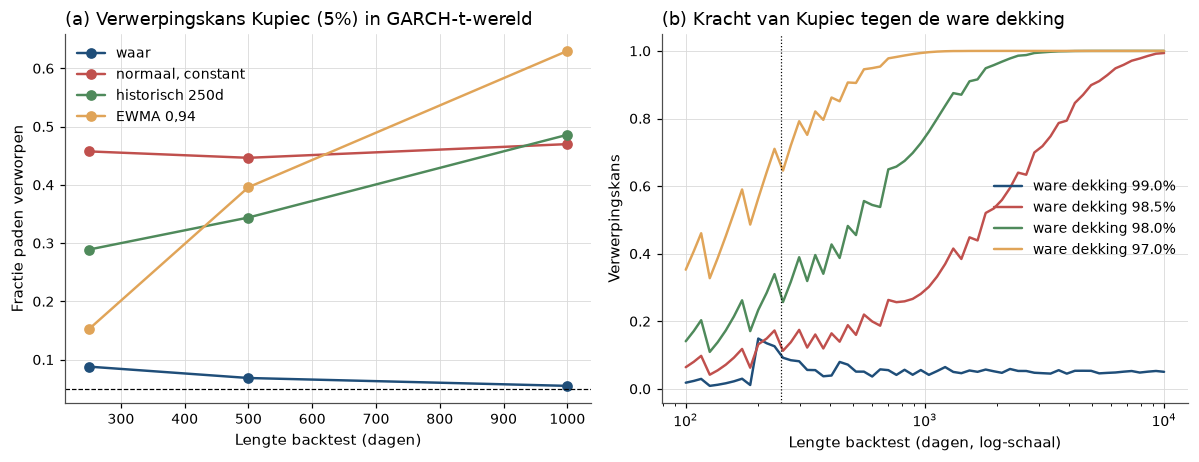

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for i, name in enumerate(hits_sim):
    rej = sim_table.loc[name, "Kupiec verwerpt"]
    axes[0].plot(rej.index, rej.values, "o-", color=hap.plotting.COLORS[i], label=name)
axes[0].axhline(0.05, color="black", lw=0.8, ls="--")
axes[0].set_title("(a) Verwerpingskans Kupiec (5%) in GARCH-t-wereld")
axes[0].set_xlabel("Lengte backtest (dagen)")
axes[0].set_ylabel("Fractie paden verworpen")
axes[0].legend()

T_grid = np.unique(np.geomspace(100, 10_000, 60).astype(int))
for i, coverage in enumerate([0.99, 0.985, 0.98, 0.97]):
    power = []
    for T in T_grid:
        x = np.arange(T + 1)
        pi_hat = x / T
        lr = -2 * ((xlogy(T - x, 0.99) + xlogy(x, 0.01)) - (xlogy(T - x, 1 - pi_hat) + xlogy(x, pi_hat)))
        power.append(stats.binom.pmf(x, T, 1 - coverage)[lr > stats.chi2.ppf(0.95, 1)].sum())
    axes[1].plot(T_grid, power, color=hap.plotting.COLORS[i], label=f"ware dekking {coverage:.1%}")
axes[1].axvline(250, color="black", lw=0.8, ls=":")
axes[1].set_xscale("log")
axes[1].set_title("(b) Kracht van Kupiec tegen de ware dekking")
axes[1].set_xlabel("Lengte backtest (dagen, log-schaal)")
axes[1].set_ylabel("Verwerpingskans")
axes[1].legend()
fig.tight_layout()
plt.show()

:::{figure} #cel-risk-management-kracht
:label: fig-risk-management-kracht
:width: 100%

Links: een statisch model met perfect gekende onvoorwaardelijke volatiliteit wordt na een
jaar in minder dan de helft van de paden verworpen, en EWMA met normale staarten in een op
de zeven. Rechts, exact binomiaal: om een model dat 98% in plaats van 99% dekt met kans 80%
te betrappen, zijn ruim vier jaar dagdata nodig. De stippellijn is het jaar van Bazel.
:::

Zelfs het ware model wordt na 250 dagen in 8,8% van de paden verworpen in plaats van 5%:
bij 2,5 verwachte overschrijdingen is de $\chi^2$-benadering grof. Het statische model wordt
op 1,5% van de dagen overschreden en in 46% van de paden verworpen, en dat stijgt
nauwelijks met de lengte (47% na 1000 dagen), omdat de overschrijdingen clusteren: een
periode zonder volatiliteitsgolf geeft het goede aantal. Christoffersen, die de clustering
moet zien, verwerpt het na een jaar in 15% en na vier jaar in 46% van de paden. EWMA wordt
door de normale staart op 1,8% van de dagen overschreden; Kupiec ziet dat na een jaar in
15% en na vier jaar in 63% van de paden. Na een jaar is het statische model in 9,2% van de
paden rood, EWMA in 1,1%. Rechts de algemene les: een model met 98% dekking wordt na 250
dagen met kans 24% verworpen, een met 98,5% met kans 11%. Een kans van 1% meten is even
moeilijk als een gemiddeld rendement meten, en om dezelfde reden.

### (b) Een convergence trade over vijf jaar

Nu [](#prop-risk-management-spiraal) op schaal. Een spreadafwijking (in basispunten) volgt
$x_{t+1} = 0{,}99\,x_t + \eta_{t+1}$, met $\eta$ een normale dagschok van 1,5 basispunt plus,
gemiddeld eens in de drie jaar, een gecompenseerde sprong van gemiddeld 30 basispunten
(exponentieel verdeeld). De positie heeft duration 5 en carry 1% per jaar. Het fonds begint
met $E_0 = 1$ en $X = LE_0$, zet de positie elke maand terug op $L$ maal het vermogen, en
moet verkopen zodra $E < hX$ met $h = 2\%$. Met fire sale verbreedt elke gedwongen verkoop
van één eenheid beginvermogen de spread met 2 basispunten, een prijsdruk die daarna even
snel terugloopt als de rest van de spread. We simuleren 4000 paden van 1260 handelsdagen,
met dezelfde schokken voor elke hefboom.

In [7]:
N_FUND, T_FUND = 4000, 1260
PHI, SIG_BP, P_JUMP, MU_JUMP, CARRY, KAPPA_FS = 0.99, 1.5, 1 / 750, 30.0, 0.01, 2.0

jump = (rng.random((T_FUND, N_FUND)) < P_JUMP) * rng.exponential(MU_JUMP, (T_FUND, N_FUND))
eta = SIG_BP * rng.standard_normal((T_FUND, N_FUND)) + jump - P_JUMP * MU_JUMP
x_spread = np.zeros((T_FUND + 1, N_FUND))
for t in range(T_FUND):
    x_spread[t + 1] = PHI * x_spread[t] + eta[t]
dx_spread = np.diff(x_spread, axis=0)
r_trade = CARRY / 252 - D * dx_spread / 1e4

sr_true = np.sqrt(252) * r_trade.mean() / r_trade.std()
sr_4y = np.sqrt(252) * r_trade[:1008].mean(axis=0) / r_trade[:1008].std(axis=0)
no_jump_4y = jump[:1008].sum(axis=0) == 0
pd.Series({"Sharpe-ratio (populatie, alle paden)": sr_true,
           "volatiliteit per jaar": np.sqrt(252) * r_trade.std(),
           "scheefheid dagrendement": stats.skew(r_trade.ravel()),
           "fractie 4-jaarsrecords zonder sprong": no_jump_4y.mean(),
           "mediane Sharpe over 4 jaar, zonder sprong": np.median(sr_4y[no_jump_4y]),
           "mediane Sharpe over 4 jaar, met sprong": np.median(sr_4y[~no_jump_4y])}).round(3)

Sharpe-ratio (populatie, alle paden)          0.584
volatiliteit per jaar                         0.017
scheefheid dagrendement                     -21.496
fractie 4-jaarsrecords zonder sprong          0.273
mediane Sharpe over 4 jaar, zonder sprong     0.880
mediane Sharpe over 4 jaar, met sprong        0.660
dtype: float64

In [8]:
def run_fund(leverage, kappa):
    """Simulate a levered convergence-trade fund with margin constraint E >= H X and fire-sale impact."""
    E = np.ones(N_FUND)
    X = leverage * E
    impact = np.zeros(N_FUND)
    alive = np.ones(N_FUND, bool)
    called = np.zeros(N_FUND, bool)
    for t in range(T_FUND):
        d_impact = (PHI - 1) * impact
        impact += d_impact
        E = np.where(alive, E + X * (CARRY / 252 - D * (dx_spread[t] + d_impact) / 1e4), E)
        for _ in range(100):                                  # forced sales until the constraint holds
            breach = alive & (X > E / H + 1e-12)
            if not breach.any():
                break
            called |= breach
            X_new = np.where(breach, np.maximum(E, 0.0) / H, X)
            widening = kappa * (X - X_new)                    # bp
            impact += widening
            E = E - X_new * D * widening / 1e4
            X = X_new
            alive &= E > 0
            X = np.where(alive, X, 0.0)
        if (t + 1) % 21 == 0:
            X = np.where(alive, leverage * E, 0.0)
    return {"P(margin call)": called.mean(), "P(ruïne)": 1 - alive.mean(),
            "mediaan eindvermogen": np.median(np.where(alive, E, 0.0))}


LEVERAGES = [1, 5, 10, 15, 20, 25, 30]
fund_no_fs = pd.DataFrame({L: run_fund(L, 0.0) for L in LEVERAGES}).T
fund_no_fs.round(3)

,P(margin call),P(ruïne),mediaan eindvermogen
1,0.000,0.000,1.052
5,0.000,0.000,1.270
10,0.009,0.002,1.573
15,0.077,0.023,1.896
20,0.210,0.061,2.232
25,0.361,0.113,2.558
30,0.500,0.168,2.846


In [9]:
fund_fs = pd.DataFrame({L: run_fund(L, KAPPA_FS) for L in LEVERAGES}).T
pd.concat({"zonder fire sale": fund_no_fs, "met fire sale": fund_fs}, axis=1).round(3)

zonder fire sale                                met fire sale           \
     P(margin call) P(ruïne) mediaan eindvermogen P(margin call) P(ruïne)   
1             0.000    0.000                1.052          0.000    0.000   
5             0.000    0.000                1.270          0.000    0.000   
10            0.009    0.002                1.573          0.009    0.002   
15            0.077    0.023                1.896          0.077    0.025   
20            0.210    0.061                2.232          0.210    0.096   
25            0.361    0.113                2.558          0.361    0.236   
30            0.500    0.168                2.846          0.500    0.397   

                         
   mediaan eindvermogen  
1                 1.052  
5                 1.270  
10                1.573  
15                1.896  
20                2.230  
25                2.520  
30                2.041

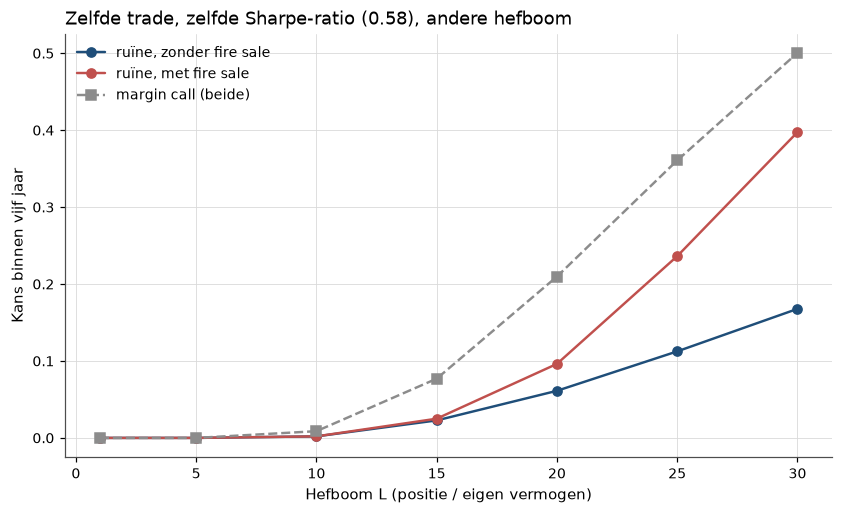

In [10]:
fig, ax = plt.subplots()
ax.plot(LEVERAGES, fund_no_fs["P(ruïne)"], "o-", color=hap.plotting.COLORS[0], label="ruïne, zonder fire sale")
ax.plot(LEVERAGES, fund_fs["P(ruïne)"], "o-", color=hap.plotting.COLORS[1], label="ruïne, met fire sale")
ax.plot(LEVERAGES, fund_no_fs["P(margin call)"], "s--", color=hap.plotting.COLORS[7], label="margin call (beide)")
ax.set_title(f"Zelfde trade, zelfde Sharpe-ratio ({sr_true:.2f}), andere hefboom")
ax.set_xlabel("Hefboom L (positie / eigen vermogen)")
ax.set_ylabel("Kans binnen vijf jaar")
ax.legend()
plt.show()

:::{figure} #cel-risk-management-ltcm-sim
:label: fig-risk-management-ltcm-sim
:width: 90%

De Sharpe-ratio van de trade is bij elke hefboom dezelfde; de kans op een margin call en op
ruïne binnen vijf jaar stijgt steil met de hefboom. Vanaf hefboom 25 verdubbelt de prijsdruk
van de eigen verkopen de kans op ruïne ruimschoots; tot hefboom 10 doet ze er niet toe.
:::

De trade heeft een Sharpe-ratio van 0,58, een volatiliteit van 1,7% per jaar en een
scheefheid van de dagrendementen van $-21$: bijna altijd een beetje winst, zelden een groot
verlies. In 27% van de vierjaarsperiodes komt geen sprong voor, en daar is de mediane
gerealiseerde Sharpe-ratio 0,88. Een fonds met vier goede jaren achter de rug, zoals LTCM in
1994–1997, kan met reden denken dat zijn trade beter is dan ze is: vier jaar data zeggen
weinig over een gemiddelde en niets over een sprong die eens in de drie jaar komt.

Zonder fire sale is de kans op ruïne binnen vijf jaar 0,2% bij $L = 10$, 6,1% bij 20, 11,3%
bij 25 en 16,8% bij 30, terwijl de mediane eindwaarde stijgt van 1,57 naar 2,85 keer het
beginvermogen: het typische pad beloont hefboom, de staart straft haar. Met fire sale blijft
de kans op een margin call gelijk, want de eerste call komt vóór elke gedwongen verkoop,
maar stijgt de kans op ruïne bij $L = 25$ naar 23,6% en bij $L = 30$ naar 39,7%. Bij
$L \le 10$ is er geen verschil: prijsdruk kost alleen iets bij een fonds dat vaak tegen zijn
limiet aan zit, zoals [](#prop-risk-management-spiraal) voorspelt.

## Replicatie op echte data

### VaR-backtest 1990–2026

```{admonition} Replicatie
:class: seealso

**Bron.** J.P. Morgan/Reuters, *RiskMetrics — Technical Document*, vierde editie 1996
{cite}`JPMorganReuters1996`; Basle Committee on Banking Supervision, *Supervisory
framework for the use of "backtesting"*, 1996 {cite}`BCBS1996b`; Kupiec 1995
{cite}`Kupiec1995`; Christoffersen 1998 {cite}`Christoffersen1998`.

**Wat.** Tabel 2 van het Bazelse kader (hierboven al exact gereproduceerd), $\lambda = 0{,}94$
uit §5.3.2.2 van RiskMetrics, en de toetsen [](#eq-risk-management-kupiec) en
[](#eq-risk-management-christoffersen) op een 99%-VaR voor één dag.

**Data hier.** Kenneth French Data Library, dagelijks marktrendement (`Mkt` = `Mkt-RF` +
`RF`) 1963-07 t/m 2026-07 via `hap.data.market_daily()`; backtest 1990-01 t/m 2026-07.

**Verschil met het origineel.** Bazel toetst handelsresultaten met wisselende posities, wij
een vaste positie in één index; RiskMetrics schatte $\lambda$ op 480 reeksen, wij passen het
toe op één. GARCH schatten we eenmaal op 1963–1989, zodat de backtest niet vooruitkijkt.

**Verwachte afwijking.** Het statische normale model moet duidelijk meer dan 1%
overschrijdingen hebben, geclusterd in crisisjaren, en door Christoffersen worden verworpen.
EWMA en GARCH moeten dichter bij 1% zitten maar erboven, door hun normale staarten. Het teken
van die afwijkingen en de rangorde statisch > aanpassend moeten kloppen.
```

In [11]:
market = hap_data.market_daily()["Mkt"].loc["1963-07-01":]
z01 = stats.norm.ppf(0.01)

var_bt = pd.DataFrame(index=market.index)
var_bt["normaal, constant"] = -(market.expanding(250).mean() + z01 * market.expanding(250).std()).shift(1)
var_bt["historisch 250d"] = -market.rolling(250).quantile(0.01).shift(1)
var_bt["EWMA 0,94"] = -z01 * np.sqrt((market**2).ewm(alpha=0.06, adjust=False).mean().shift(1))

garch = arch_model(100 * market, mean="Constant", vol="GARCH", p=1, q=1, dist="normal")
garch_fit = garch.fit(last_obs="1990-01-01", disp="off")
garch_fc = garch_fit.forecast(start="1990-01-01", horizon=1, reindex=False)
var_bt["GARCH(1,1)"] = (-(garch_fit.params["mu"] + z01 * np.sqrt(garch_fc.variance["h.1"])) / 100).shift(1)

var_bt = var_bt.loc["1990-01-01":].dropna()
loss_bt = -market.loc[var_bt.index]
hits_bt = var_bt.lt(loss_bt, axis=0).astype(int)
garch_fit.params.round(4)

mu          0.0634
omega       0.0057
alpha[1]    0.0921
beta[1]     0.9047
Name: params, dtype: float64

In [12]:
full_years = hits_bt.loc[:"2025"]
by_year = full_years.groupby(full_years.index.year)
summary_bt = {}
for name in hits_bt:
    lr_ind, lr_cc = christoffersen_lr(hits_bt[name].to_numpy())
    lr_pof = kupiec_lr(hits_bt[name].to_numpy())
    yearly_counts = by_year[name].sum()
    yearly_cc = by_year[name].apply(lambda h: christoffersen_lr(h.to_numpy())[1])
    summary_bt[name] = {"dagen": len(hits_bt), "overschrijdingen": hits_bt[name].sum(),
                        "fractie (%)": 100 * hits_bt[name].mean(),
                        "LR_pof": lr_pof, "LR_ind": lr_ind, "LR_cc": lr_cc,
                        "p-waarde cc": stats.chi2.sf(lr_cc, 2),
                        "dagen met twee op rij": int((hits_bt[name] * hits_bt[name].shift(1)).sum()),
                        "jaren groen": (yearly_counts <= 4).sum(), "jaren geel": yearly_counts.between(5, 9).sum(),
                        "jaren rood": (yearly_counts >= 10).sum(),
                        "jaren cc verworpen": (yearly_cc > stats.chi2.ppf(0.95, 2)).sum()}
pd.DataFrame(summary_bt).T.round(3)

,dagen,overschrijdingen,fractie (%),LR_pof,LR_ind,LR_cc,p-waarde cc,dagen met twee op rij,jaren groen,jaren geel,jaren rood,jaren cc verworpen
"normaal, constant",9211.0,300.0,3.257,297.475,27.284,324.759,0.0,29.0,18.0,7.0,11.0,15.0
historisch 250d,9211.0,150.0,1.628,30.884,23.911,54.795,0.0,13.0,22.0,12.0,2.0,8.0
"EWMA 0,94",9211.0,182.0,1.976,69.001,6.038,75.039,0.0,9.0,16.0,18.0,2.0,7.0
"GARCH(1,1)",9211.0,198.0,2.150,92.507,4.227,96.734,0.0,9.0,15.0,20.0,1.0,10.0


In [13]:
yearly = hits_bt.groupby(hits_bt.index.year).sum()
yearly.loc[[1997, 1998, 1999, 2000, 2002, 2007, 2008, 2009, 2011, 2020, 2022]]

,"normaal, constant",historisch 250d,"EWMA 0,94","GARCH(1,1)"
date,,,,
1997,7,5,6,7
1998,16,5,7,9
1999,12,1,2,3
2000,24,7,3,4
2002,28,5,2,2
2007,10,9,10,9
2008,38,15,7,9
2009,21,0,1,5
2011,16,6,7,8


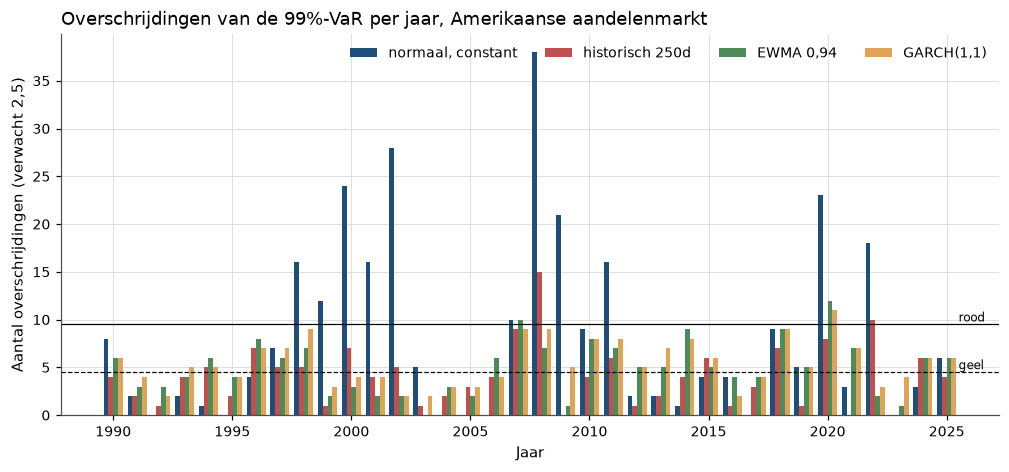

In [14]:
fig, ax = plt.subplots(figsize=(11, 4.5))
years = yearly.loc[:2025].index
width = 0.2
for i, name in enumerate(yearly):
    ax.bar(years + (i - 1.5) * width, yearly.loc[:2025, name], width=width, color=hap.plotting.COLORS[i], label=name)
ax.axhline(4.5, color="black", lw=0.8, ls="--")
ax.axhline(9.5, color="black", lw=0.8)
ax.text(years[-1] + 0.5, 4.8, "geel", fontsize=8)
ax.text(years[-1] + 0.5, 9.8, "rood", fontsize=8)
ax.set_title("Overschrijdingen van de 99%-VaR per jaar, Amerikaanse aandelenmarkt")
ax.set_xlabel("Jaar")
ax.set_ylabel("Aantal overschrijdingen (verwacht 2,5)")
ax.legend(ncol=4)
plt.show()

:::{figure} #cel-risk-management-jaren
:label: fig-risk-management-jaren
:width: 100%

Het statische normale model is rood rond 2000 en in 2008 en haast groen in de rustige jaren:
zijn overschrijdingen clusteren. De aanpassende modellen zijn meestal groen of geel, maar het
historische model is rood in 2008 en 2022, EWMA in 2007 en 2020 en GARCH in 2020.
:::

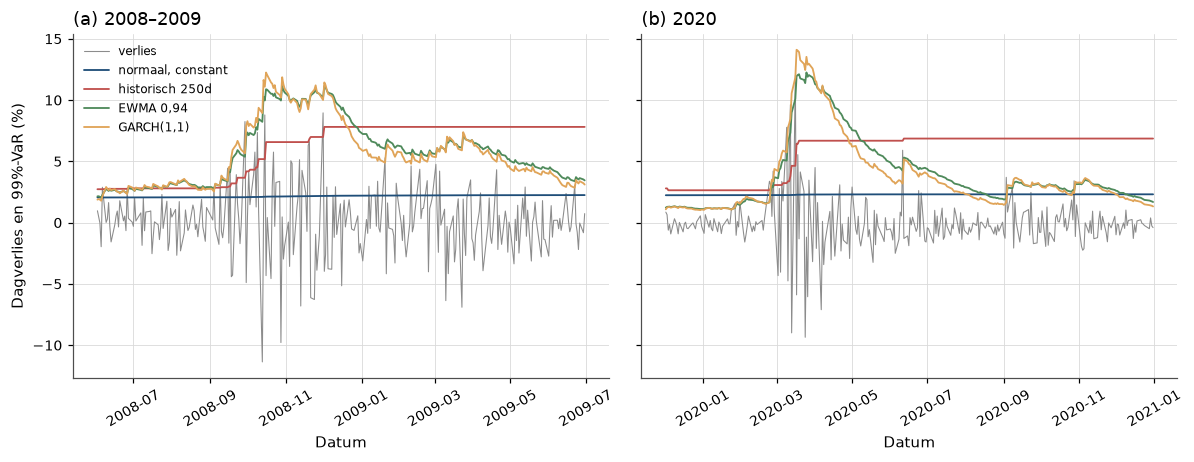

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), sharey=True)
for ax, (start_c, end_c, title) in zip(axes, [("2008-06-01", "2009-06-30", "(a) 2008–2009"),
                                              ("2019-12-01", "2020-12-31", "(b) 2020")], strict=True):
    loss_c = 100 * loss_bt.loc[start_c:end_c]
    ax.plot(loss_c.index, loss_c, color=hap.plotting.COLORS[7], lw=0.7, label="verlies")
    for i, name in enumerate(var_bt):
        ax.plot(loss_c.index, 100 * var_bt.loc[start_c:end_c, name], color=hap.plotting.COLORS[i], lw=1.2, label=name)
    ax.set_title(title)
    ax.set_xlabel("Datum")
    ax.tick_params(axis="x", rotation=30)
axes[0].set_ylabel("Dagverlies en 99%-VaR (%)")
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

:::{figure} #cel-risk-management-crises
:label: fig-risk-management-crises
:width: 100%

In 2008 liep de volatiliteit in weken op en EWMA en GARCH liepen mee; het historische model
steeg in trappen en bleef daarna een jaar te hoog. In februari 2020 stond de VaR van alle
modellen laag toen de eerste grote verliezen kwamen.
:::

Het GARCH-model heeft $a = 0{,}092$ en $b = 0{,}905$, een persistentie van 0,997, dicht bij
de IGARCH van RiskMetrics. Het statische model wordt op 3,3% van de 9211 dagen overschreden,
is in 11 van de 36 volle jaren rood en heeft 29 keer twee overschrijdingen op rij, waar bij
zijn eigen frequentie ongeveer tien te verwachten zijn. Historische simulatie (1,6%), EWMA
(2,0%) en GARCH (2,2%) zitten dichter bij 1%, met twee, twee en één rood jaar. Over 36 jaar
verwerpt Christoffersen alle vier met een $p$-waarde van nul: met 9211 dagen heeft de toets
de kracht die hij met 250 mist, en dan is ook 2% te veel. $\mathrm{LR}_{\mathrm{ind}}$
scheidt de modellen wel: 27,3 en 23,9 voor statisch en historisch, 6,0 en 4,2 voor EWMA en
GARCH, bij een kritieke waarde van 3,84.

In 1998 is het statische model rood (16) en zijn de andere groen of geel (5, 7, 9). Op 4, 27
en 31 augustus werden alle vier overschreden; de zes overschrijdingen tussen 10 september en
5 oktober kwamen alleen nog bij het statische model, omdat de andere zich in weken hadden
aangepast. In 2008 zijn het statische (38) en het historische model (15) rood, EWMA (7) en
GARCH (9) geel. In 2020 zijn EWMA (12) en GARCH (11) rood. De verwachting klopt in teken en
rangorde, maar de snelle modellen falen niet in 2008 maar in 2020: in 2008 bouwde de
volatiliteit zich over maanden op, in februari 2020 sprong ze vanuit een van de rustigste
periodes van de steekproef. Een model dat van gisteren leert, ziet een sprong vanuit rust
niet aankomen.

### De spreads van 1998

```{admonition} Replicatie
:class: seealso

**Bron.** President's Working Group on Financial Markets, *Hedge Funds, Leverage, and the
Lessons of Long-Term Capital Management*, april 1999 {cite}`PresidentsWorkingGroup1999`;
Jorion 2000 {cite}`Jorion2000`.

**Wat.** Het rapport (p. 12 en 16): na de Russische devaluatie en het moratorium van 17
augustus 1998 "risk spreads and liquidity premiums rose sharply in markets around the
world", terwijl LTCM "was betting in general that liquidity, credit and volatility spreads
would narrow from historically high levels".

**Data hier.** FRED, dagelijks: `BAA10Y` en `AAA10Y` (Moody's Baa- en Aaa-rendementen min de
tienjaars staatsrente), `TEDRATE` (driemaands Eurodollar min T-bill) en `DGS10`, via
`hap.data.fred(...)`.

**Verschil met het origineel.** De posities van LTCM zijn niet publiek; we tonen alleen dat
het soort spreads waarop het fonds wedde, verbreedde. Swap spreads staan voor 1998 niet
gratis in FRED (`DSWP10` begint in juli 2000).

**Verwachte afwijking.** Alle drie de spreads moeten tussen half augustus en half oktober
1998 met tientallen basispunten verbreden, veel meer dan de dagschommelingen van 1997
verwachten, terwijl de tienjaars staatsrente daalt (vlucht naar kwaliteit).
```

In [16]:
spreads = pd.concat([hap_data.fred(s)[s] for s in ["BAA10Y", "AAA10Y", "TEDRATE", "DGS10"]], axis=1, sort=True)
spreads = spreads.loc["1997-01-01":"1999-12-31"].dropna()
before = spreads.loc[:"1998-08-14"].iloc[-1]
crisis = spreads.loc["1998-08-17":"1998-10-31"]
extreme = pd.concat([crisis[["BAA10Y", "AAA10Y", "TEDRATE"]].max(), crisis[["DGS10"]].min()])
extreme_date = pd.concat([crisis[["BAA10Y", "AAA10Y", "TEDRATE"]].idxmax(), crisis[["DGS10"]].idxmin()])
n_days_move = pd.Series({s: len(spreads.loc["1998-08-15":extreme_date[s]]) for s in spreads})
sd_1997 = spreads.loc["1997"].diff().std()
pd.DataFrame({"14 aug 1998 (%)": before, "extreem aug-okt (%)": extreme, "datum": extreme_date.dt.date,
              "verandering (bp)": 100 * (extreme - before),
              "SD dagverandering 1997 (bp)": 100 * sd_1997,
              "in SD's (sqrt-tijd)": (extreme - before) / (sd_1997 * np.sqrt(n_days_move))}).round(2)

,14 aug 1998 (%),extreem aug-okt (%),datum,verandering (bp),SD dagverandering 1997 (bp),in SD's (sqrt-tijd)
BAA10Y,1.74,2.77,1998-10-16,103.0,2.39,6.64
AAA10Y,1.12,1.96,1998-10-16,84.0,1.98,6.55
TEDRATE,0.79,1.66,1998-10-16,87.0,4.57,2.94
DGS10,5.40,4.16,1998-10-05,-124.0,4.92,-4.32


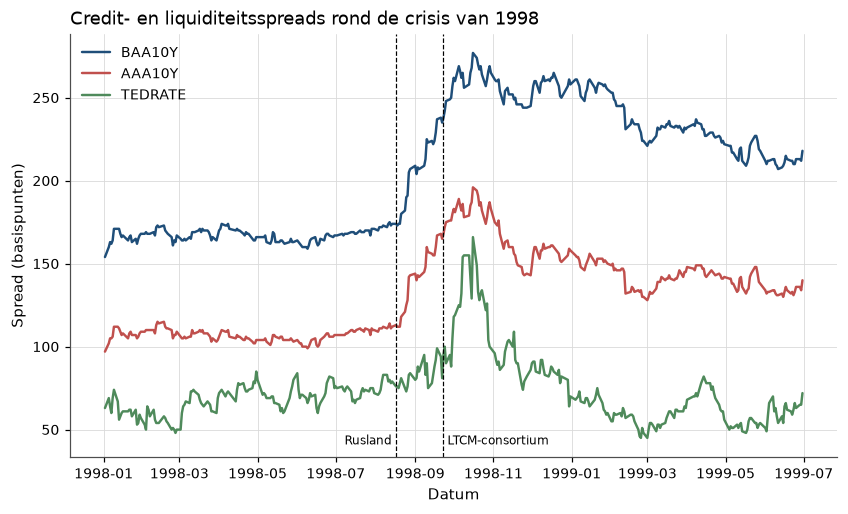

In [17]:
fig, ax = plt.subplots()
window = spreads.loc["1998-01-01":"1999-06-30"]
for i, s in enumerate(["BAA10Y", "AAA10Y", "TEDRATE"]):
    ax.plot(window.index, 100 * window[s], color=hap.plotting.COLORS[i], label=s)
for date, text, align in [("1998-08-17", "Rusland ", "right"), ("1998-09-23", " LTCM-consortium", "left")]:
    ax.axvline(pd.Timestamp(date), color="black", lw=0.8, ls="--")
    ax.text(pd.Timestamp(date), 0.03, text, fontsize=8, ha=align, transform=ax.get_xaxis_transform())
ax.set_title("Credit- en liquiditeitsspreads rond de crisis van 1998")
ax.set_xlabel("Datum")
ax.set_ylabel("Spread (basispunten)")
ax.legend(loc="upper left")
plt.show()

:::{figure} #cel-risk-management-spreads
:label: fig-risk-management-spreads
:width: 90%

Na 17 augustus verbreedden de bedrijfsobligatiespreads en de TED-spread in weken met meer dan
tachtig basispunten; de piek viel pas in oktober, na de redding van LTCM, en begin 1999 waren
de bedrijfsobligatiespreads nog niet terug op hun niveau van juli 1998.
:::

Tussen 14 augustus en 16 oktober 1998 verbreedde de Baa-spread met 103, de Aaa-spread met 84
en de TED-spread met 87 basispunten; de tienjaarsrente daalde tot 5 oktober met 124
basispunten. Gemeten in de dagschommelingen van 1997, opgeschaald met de wortel uit het aantal
handelsdagen, zijn de bewegingen in de bedrijfsobligatiespreads 6,6 standaarddeviaties, met
onder normaliteit een kans van ongeveer twee op honderd miljard. Dat bewijst niet dat de
wereld niet normaal is (1997 was rustig, en dagveranderingen van Moody's-reeksen zijn niet
onafhankelijk), maar het is wat een model ziet dat "during more stable periods" is geschat.

Naast toy-voorbeeld (c): een fonds met hefboom 25, duration 5 en haircut 2% krijgt zijn
margin call na 40 basispunten en is failliet na 80, dus een beweging als die van de
Aaa-spread is genoeg; met hefboom 10 was er geen margin call geweest. De werkelijke posities,
durations en haircuts van LTCM kennen we niet. Het rapport geeft wel de afloop: 4,1 miljard
kapitaal op 31 juli, 1,8 miljard verlies in augustus, en op 23 september nam een consortium
van veertien instellingen, bijeengebracht bij de Federal Reserve Bank of New York, voor
ongeveer 3,6 miljard dollar 90% van het fonds over (p. 12–14). Het vaak genoemde
totaalverlies van ongeveer 4,6 miljard dollar {cite}`Lowenstein2000` hebben we niet in een
primaire bron kunnen verifiëren.

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** VaR gaf risicobeheer een gemeenschappelijke taal en een getal
voor limieten en kapitaal. Het gebruikt wat meetbaar is, het tweede moment, en laat weg wat
niet meetbaar is. Het werkt redelijk: in onze backtest liggen de aanpassende modellen op
1,6 tot 2,2% overschrijdingen tegen 3,3% voor een statisch model, meestal in het groene of
gele gebied. Kupiec en Christoffersen maakten een risicomodel weerlegbaar, en de
coherentie-axioma's belandden in 2016 in de regels.

**Waar het breekt.** Waar het getal niets over zegt. Een 99%-VaR die in 2020 twaalf keer
wordt overschreden, is geen goed model met pech. Het soort spreads waarop LTCM wedde, bewoog
in twee maanden ruim zes standaarddeviaties; het rapport schreef dat de verliezen "greatly
exceeded what conventional risk models, estimated during more stable periods, suggested were
probable" (p. 12). Santa-Clara: LTCM en "the whole dealer system in 2008 had risk
departments, models and limits, and were destroyed by losses their models had called
impossible" {cite}`SantaClara2026`. Het diepste gebrek was de aanname dat een positie tegen
de marktprijs kan worden gesloten: in onze simulatie heeft dezelfde trade met dezelfde
Sharpe-ratio een kans op ruïne van bijna nul of bijna een op vier, afhankelijk van hefboom en
eigen prijsdruk.

**Risico of vergissing?** De Chicago-lezing: de spreads van 1997 waren een beloning voor
liquiditeits- en crashrisico, en augustus 1998 was de slechte toestand waarvoor die beloning
werd betaald. LTCM droeg beprijsd risico met te weinig kapitaal, en dat het fonds de toestand
niet overleefde, bewijst niet dat de prijzen verkeerd waren. De Yale-lezing, van
{cite:t}`ShleiferVishny1997`: de spreads werden groter dan hun fundamentele waarde *omdat*
arbitrageurs moesten verkopen, en LTCM dacht iets te weten wat de prijs niet wist. Dat de
spreads begin 1999 deels terugliepen, past bij beide. Scheiden zou kunnen met de posities en
verkopen van de arbitrageurs, gekoppeld aan hoe snel spreads daarna terugliepen; die data is
voor 1998 niet publiek, en één episode is geen steekproef. Het praktijkmotief zegt hier iets
over het fonds, niet over de prijzen: het rendement kwam uit beprijsd risico, het verlies uit
de overtuiging dat de hefboom veilig was.

**Wat er daarna kwam.** Als arbitrageurs een mispricing niet kunnen wegwerken omdat hun
financiering verdwijnt, is de vraag wie de prijzen dan zet en waarom beleggers afwijken:
[behavioral finance en limits of arbitrage](#04-23-behavioral).

## Oefeningen

:::{exercise}
:label: ex-risk-management-1

**ES en VaR bij dikke staarten.** Laat $L = \sigma T_\nu\sqrt{(\nu-2)/\nu}$ met $T_\nu$
Student-$t$, zodat $\SD(L) = \sigma$.

1. Laat zien dat $\mathrm{ES}_\alpha(T_\nu) = \dfrac{f_\nu(t_\alpha)}{1-\alpha}\cdot\dfrac{\nu + t_\alpha^2}{\nu-1}$,
   met $f_\nu$ de dichtheid en $t_\alpha$ het $\alpha$-kwantiel van $T_\nu$.
2. Bereken voor $\nu \in \{4, 6, 10, \infty\}$ de verhouding $\mathrm{ES}_{0{,}975}/\mathrm{VaR}_{0{,}99}$.
3. Wat betekent dat voor het kapitaal onder de regels van 2016 tegenover 1996?
:::

:::{solution} ex-risk-management-1
:class: dropdown

**(1)** Differentieer $f_\nu(t) \propto (1+t^2/\nu)^{-(\nu+1)/2}$: dan is
$\frac{\mathrm{d}}{\mathrm{d}t}\left[\frac{\nu+t^2}{\nu-1}f_\nu(t)\right] = -t f_\nu(t)$, dus
$\int_{t_\alpha}^\infty t f_\nu(t)\,\mathrm{d}t = \frac{\nu+t_\alpha^2}{\nu-1}f_\nu(t_\alpha)$.
Deel door $1-\alpha$.

In [18]:
def t_scaled(alpha, nu):
    """Standardised (unit variance) Student-t VaR and ES at level alpha."""
    if np.isinf(nu):
        z = stats.norm.ppf(alpha)
        return z, stats.norm.pdf(z) / (1 - alpha)
    q = stats.t.ppf(alpha, nu)
    es = stats.t.pdf(q, nu) / (1 - alpha) * (nu + q**2) / (nu - 1)
    scale = np.sqrt((nu - 2) / nu)
    return q * scale, es * scale


es_check = stats.t.expect(lambda x: x, args=(6,), lb=stats.t.ppf(0.975, 6)) / 0.025
print(f"controle nu = 6: formule {t_scaled(0.975, 6)[1] / np.sqrt(4 / 6):.4f}, numeriek {es_check:.4f}")
pd.DataFrame({nu: {"VaR 99%": t_scaled(0.99, nu)[0], "ES 97,5%": t_scaled(0.975, nu)[1],
                   "ES 97,5% / VaR 99%": t_scaled(0.975, nu)[1] / t_scaled(0.99, nu)[0]}
              for nu in (4, 6, 10, np.inf)}).T.round(3)

controle nu = 6: formule 3.2562, numeriek 3.2562


,VaR 99%,"ES 97,5%","ES 97,5% / VaR 99%"
4.0,2.649,2.824,1.066
6.0,2.566,2.659,1.036
10.0,2.472,2.521,1.020
inf,2.326,2.338,1.005


De verhouding is 1,005 bij normaliteit, 1,020 bij $\nu = 10$, 1,036 bij $\nu = 6$ en 1,066
bij $\nu = 4$. Bij gelijke volatiliteit ligt de 99%-VaR van een dikstaartige verdeling al
hoger (2,65 tegen 2,33 bij $\nu = 4$), en de ES stijgt nog iets meer. De overstap laat het
kapitaal onder normaliteit gelijk en maakt dikke staarten duurder, precies de zwakte die
Santa-Clara noemt. (De kalibratie op een stressperiode in 2016 zit niet in deze oefening.)
:::

:::{exercise}
:label: ex-risk-management-2

**Tabel 1 van Bazel.** (1) Bereken voor 250 dagen de kans dat een model met ware dekking
98%, 97% en 95% groen is; vergelijk met de "type 2"-kolom bij vijf overschrijdingen in tabel
1 van het kader (43,9%, 12,8%, 0,5%). (2) Hoeveel dagen zijn nodig voordat Kupiec op 5% een
model met 98% dekking in minstens 80% van de gevallen verwerpt?
:::

:::{solution} ex-risk-management-2
:class: dropdown

In [19]:
green = {c: round(float(stats.binom.cdf(4, 250, 1 - c)), 3) for c in (0.98, 0.97, 0.95)}
print("P(groen):", green)


def kupiec_power(T, coverage, level=0.05):
    """Exact power of the Kupiec POF test against a model with the given true coverage."""
    x = np.arange(T + 1)
    pi_hat = x / T
    lr = -2 * ((xlogy(T - x, 0.99) + xlogy(x, 0.01)) - (xlogy(T - x, 1 - pi_hat) + xlogy(x, pi_hat)))
    return stats.binom.pmf(x, T, 1 - coverage)[lr > stats.chi2.ppf(1 - level, 1)].sum()


T_needed = next(T for T in range(250, 5000, 10) if kupiec_power(T, 0.98) >= 0.80)
print(f"dagen nodig voor 80% kracht tegen 98% dekking: {T_needed} (= {T_needed / 250:.1f} jaar)")

P(groen): {0.98: 0.439, 0.97: 0.128, 0.95: 0.005}


dagen nodig voor 80% kracht tegen 98% dekking: 1070 (= 4.3 jaar)


De kansen zijn 43,9%, 12,8% en 0,5%, precies tabel 1. Voor 80% kracht zijn ruim vier jaar
dagdata nodig; door de discrete verdeling stijgt de kracht niet monotoon, dus het precieze
getal kan een paar dagen verschuiven. Een zeldzame gebeurtenis meten is als een gemiddeld
rendement meten: de standaardfout daalt met $1/\sqrt{T}$, en de grootheid zelf is klein.
:::

:::{exercise}
:label: ex-risk-management-3

**Filtered historical simulation.** Voeg aan de backtest van 1990–2026 toe: (i) GARCH(1,1)
met gestandaardiseerde Student-$t$-schokken, geschat op 1963–1989; (ii) filtered historical
simulation: deel de rendementen door de EWMA-volatiliteit, neem het 1%-kwantiel van de
gestandaardiseerde rendementen over 1000 dagen, en vermenigvuldig met de EWMA-volatiliteit
van morgen. Rapporteer overschrijdingen, rode jaren en de aantallen in 1998, 2008 en 2020.
:::

:::{solution} ex-risk-management-3
:class: dropdown

In [20]:
garch_t = arch_model(100 * market, mean="Constant", vol="GARCH", p=1, q=1, dist="t")
garch_t_fit = garch_t.fit(last_obs="1990-01-01", disp="off")
nu_hat = garch_t_fit.params["nu"]
q01_t = stats.t.ppf(0.01, nu_hat) * np.sqrt((nu_hat - 2) / nu_hat)
fc_t = garch_t_fit.forecast(start="1990-01-01", horizon=1, reindex=False)
var_garch_t = (-(garch_t_fit.params["mu"] + q01_t * np.sqrt(fc_t.variance["h.1"])) / 100).shift(1)

ewma_sd = np.sqrt((market**2).ewm(alpha=0.06, adjust=False).mean())
standardised = market / ewma_sd.shift(1)
var_fhs = -(standardised.rolling(1000).quantile(0.01) * ewma_sd).shift(1)

extra = pd.DataFrame({"GARCH-t": var_garch_t, "FHS (EWMA)": var_fhs}).reindex(var_bt.index)
hits_extra = extra.lt(loss_bt, axis=0).astype(int)
yearly_extra = hits_extra.groupby(hits_extra.index.year).sum()
pd.DataFrame({name: {"nu": nu_hat if name == "GARCH-t" else np.nan,
                     "overschrijdingen": hits_extra[name].sum(),
                     "fractie (%)": 100 * hits_extra[name].mean(),
                     "jaren rood (t/m 2025)": (yearly_extra.loc[:2025, name] >= 10).sum(),
                     "1998": yearly_extra.loc[1998, name], "2008": yearly_extra.loc[2008, name],
                     "2020": yearly_extra.loc[2020, name]} for name in extra}).T.round(3)

,nu,overschrijdingen,fractie (%),jaren rood (t/m 2025),1998,2008,2020
GARCH-t,7.446,156.0,1.694,1.0,6.0,6.0,10.0
FHS (EWMA),NaN,107.0,1.162,0.0,5.0,4.0,4.0


Met $t$-schokken ($\hat\nu = 7{,}4$) daalt het aantal GARCH-overschrijdingen van 198 naar 156
(1,7%), maar 2020 blijft rood (10). FHS komt met 107 (1,16%) het dichtst bij 1%, zonder rood
jaar, met vijf, vier en vier overschrijdingen in 1998, 2008 en 2020. De $t$-verdeling
repareert de staart; FHS haalt de staart uit de data en het niveau uit EWMA, en pakt zo beide
fouten uit de backtest aan. Geen van beide ziet de sprong vanuit rust: ook FHS wordt in 2020
vaker overschreden dan de 2,5 keer die bij een juist model hoort. De meeste falen van VaR
komen dus niet uit het idee maar uit de normale staart en de trage aanpassing.
:::